# Classification in Practice: Metrics, Calibration & Threshold Tuning

This notebook brings together three skills that support each other:

1. **which metrics to use**
2. **when and how to calibrate probabilities**
3. **how to choose a decision threshold**

For each, we briefly explain the idea and why it matters, then show minimal code.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [2]:
from sklearn.datasets import fetch_openml

diabetes = fetch_openml(data_id=37, as_frame=True, parser="pandas")
X, y = diabetes.data, diabetes.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, random_state=42, test_size=0.4
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000)),
])
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)

---

## Part 1: Classification Metrics

### Why it matters

The model trains by minimizing a **loss** (e.g. log-loss). What we actually care about in practice is an **evaluation metric** (e.g. recall, precision). Think of it like training for one kind of race but being judged on another: the loss is a stand-in for the metric we want, so we need to choose and report metrics that match our goal.

**Accuracy** is (TP + TN) / total—the fraction of correct predictions. The catch: when one class is much rarer (e.g. “donated” vs “not donated”), a model that *always* predicts the majority class can get high accuracy without learning to spot the minority at all. It’s like acing a test where 76% of the questions are “answer no”—you can do well by never saying “yes,” but that doesn’t mean you understand the “yes” cases.

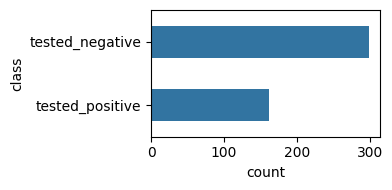

In [3]:
plt.figure(figsize=(4, 2))
sns.countplot(
    y=y_train,
    orient="horizontal",
    width=0.5,
)
plt.tight_layout()

In [4]:
from sklearn.metrics import accuracy_score
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

print(f"LogisticRegression accuracy:      {accuracy_score(y_test, y_pred):.3f}")
print(f"Dummy (always majority) accuracy: {accuracy_score(y_test, dummy_pred):.3f}")

LogisticRegression accuracy:      0.737
Dummy (always majority) accuracy: 0.653


**Balanced accuracy** averages recall over both classes, so the majority class can’t dominate the number. Below we report it for our model.

In [5]:
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, f1_score

print(f"LogisticRegression balanced_acc: {balanced_accuracy_score(y_test, y_pred):.3f}")

LogisticRegression balanced_acc: 0.691


**Takeaway:** With imbalanced classes, don't rely on accuracy alone. Use **precision and recall** for the class you care about, or **balanced accuracy** to give both classes equal weight.


## Confusion matrix and derived metrics

A useful way to see where the model goes wrong is the **confusion matrix**:

|       A/P          | Predicted + | Predicted − |
|-----------------|-------------|-------------|
| **Actual +**    | TP          | FN          |
| **Actual −**    | FP          | TN          |

From it we get two questions that matter in many applications:

- **Precision** = TP / (TP + FP): *When the model says “positive,” how often is it right?* (Like: of the search results you clicked, how many were actually relevant?)
- **Recall** = TP / (TP + FN): *Of all real positives, how many did we find?* (Like: of all relevant pages, how many did we show?)

You can’t usually maximize both at once. If we raise the decision threshold, we predict “positive” less often: we get fewer false positives (precision goes up) but miss more real positives (recall goes down). The curves in the next section show this trade-off for every possible threshold.

Precision (tested_positive): 0.644
Recall (tested_positive):    0.542
F1 (tested_positive):         0.589


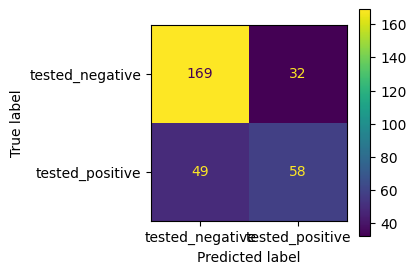

In [6]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
)

pos_label = "tested_positive"

print(f"Precision ({pos_label}): {precision_score(y_test, y_pred, pos_label=pos_label):.3f}")
print(f"Recall ({pos_label}):    {recall_score(y_test, y_pred, pos_label=pos_label):.3f}")
print(f"F1 ({pos_label}):         {f1_score(y_test, y_pred, pos_label=pos_label):.3f}")

fig, ax = plt.subplots(figsize=(4, 3))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax)
plt.tight_layout()
plt.show()

In [7]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel().tolist()

print(f"True negatives: {tn}")
print(f"False positives: {fp}")
print(f"False negatives: {fn}")
print(f"True positives: {tp}")

True negatives: 169
False positives: 32
False negatives: 49
True positives: 58


### Threshold Curves

Evaluating a model on a single threshold (e.g. 0.5); resulting in one confusion matrix, doesn't give the full picture. We need to vary the threshold, evaluate the model, and collect data points resulting in the PR-curve.

Curves show the full trade-off so you can pick a threshold later. Later we'll be using a **meta-estimator** to tune the threshold automatically.

#### 1. Precision-Recall Curve

A **Precision–Recall (PR) curve** shows how **precision** and **recall** trade off as the decision threshold changes.

**Axes:**
- **X-axis: Recall** — fraction of actual positives that are correctly predicted (sensitivity).
- **Y-axis: Precision** — of the predicted positives, how many are correct.

Each point on the curve corresponds to one threshold (and thus one confusion matrix). A good classifier has high precision and high recall, so the curve bends toward the **top-right** corner. PR curves are especially useful when the positive class is rare or imbalanced, because they focus on the positive class and ignore true negatives.

**Average precision (AP)** is the area under the PR curve: it summarizes how well the classifier ranks positives vs negatives; higher is better (max 1.0).

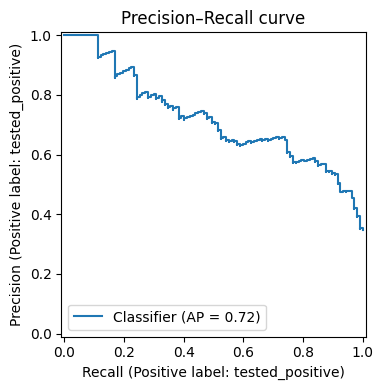

Average precision: 0.722


In [8]:
from sklearn.metrics import (
    PrecisionRecallDisplay,
    average_precision_score,
)

y_proba = pipe.predict_proba(X_test)[:, 1]  # P(positive)

fig, ax = plt.subplots(figsize=(5, 4))
PrecisionRecallDisplay.from_predictions(y_test, y_proba, pos_label=pos_label, ax=ax)
ax.set_title("Precision–Recall curve")
plt.tight_layout()
plt.show()

print(f"Average precision: {average_precision_score(y_test, y_proba, pos_label=pos_label):.3f}")

#### 2. ROC-Curve

An **ROC curve** (Receiver Operating Characteristic curve) shows how well a **binary classifier** performs across all possible **decision thresholds**.

**Axes:**
- **X-axis: False Positive Rate (FPR)** — fraction of negatives incorrectly predicted as positive.
- **Y-axis: True Positive Rate (TPR)** — fraction of positives correctly predicted (same as recall/sensitivity).

Each point on the curve corresponds to one threshold: "If I use this threshold, I get this (FPR, TPR)." A good classifier has high TPR with low FPR, so the curve bends toward the **top-left** corner. A random classifier follows the diagonal; a perfect one goes straight up then right.

**ROC-AUC** (area under the curve) summarizes overall performance: 0.5 = random, 1.0 = perfect; values above 0.8 are typically considered good.



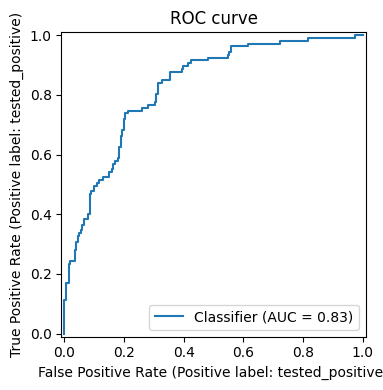

ROC-AUC: 0.827


In [9]:
from sklearn.metrics import RocCurveDisplay, roc_auc_score

fig, ax = plt.subplots(figsize=(5, 4))
RocCurveDisplay.from_predictions(y_test, y_proba, pos_label=pos_label, ax=ax)
ax.set_title("ROC curve")
plt.tight_layout()
plt.show()

print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.3f}")

#### When to use which?

If you are looking for a "fair" assessment of a model's ability to distinguish between two groups regardless of how many people are in each group, use **ROC**.

If you are working on a problem where the "Positive" cases are rare (like fraud detection or rare disease screening) and you need to know how much you can trust a "Positive" result, use **PR**.

---

## Part 2: Probability Calibration

### Why it matters

**Well-calibrated** means: among samples where the model outputs probability ≈ 0.8, about 80% should be positive. Think of a weather forecaster: when they say "80% chance of rain" on many days, it should rain on about 80% of those days. Calibration is the same idea for model probabilities. Many models (e.g. Naive Bayes, Random Forest, SVM) output scores that are **not** well-calibrated—they’re useful for ranking but not as literal probabilities.

**When to calibrate:** When you need interpretable probabilities (e.g. for threshold tuning, cost-sensitive decisions, or reporting “confidence”).

### How: calibration curve and CalibratedClassifierCV

A **calibration curve** (reliability diagram) plots *mean predicted probability* (binned) vs *fraction of positives* in each bin. A well-calibrated model lies on the diagonal.

**CalibratedClassifierCV** fits a calibrator (e.g. isotonic regression or sigmoid) on **held-out data** (not the same as training the base model) so that the mapping from raw scores to probabilities is unbiased. We use held-out data for the same reason we don't grade our own exam—we need an unbiased view of how the model actually performs.

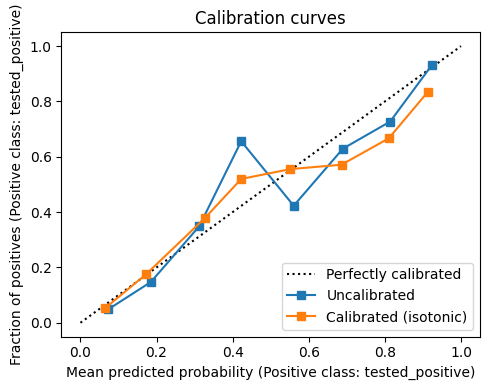

In [10]:
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV

# Base model (no calibration)
pipe_uncal = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000)),
])
pipe_uncal.fit(X_train, y_train)

# Calibrated: fit calibrator on CV folds (avoids using training predictions)
pipe_cal = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", CalibratedClassifierCV(
        LogisticRegression(max_iter=1000),
        method="isotonic",
        cv=3,
    )),
])
pipe_cal.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(5, 4))
CalibrationDisplay.from_estimator(pipe_uncal, X_test, y_test, n_bins=8, ax=ax, name="Uncalibrated")
CalibrationDisplay.from_estimator(pipe_cal, X_test, y_test, n_bins=8, ax=ax, name="Calibrated (isotonic)")
ax.set_title("Calibration curves")
plt.tight_layout()
plt.show()

**Tip:** Use `cv` in `CalibratedClassifierCV` so the calibrator sees out-of-fold predictions; fitting it on the same data as the classifier would be optimistic.

---

## Part 3: Tuning the Decision Threshold

### Why it matters

`predict()` uses a default threshold (0.5 on probabilities, or 0 on decision function). That default is **rarely optimal** for your metric or business cost. For blood donation we might prefer to catch more donors (higher recall, more false alarms) or fewer false alarms (higher precision, miss some donors). The threshold is the dial that trades off:

- **Precision** ↑ as threshold ↑ (fewer FP).
- **Recall** ↑ as threshold ↓ (fewer FN).

So we **tune the threshold** to maximize the metric we care about (e.g. balanced accuracy, F1) or to minimize a custom cost (e.g. cost of FP vs FN).

### How: TunedThresholdClassifierCV

`TunedThresholdClassifierCV` wraps a fitted (or unfitted) classifier and, via cross-validation, finds the threshold that optimizes a given `scoring` function. Only the threshold changes; the model parameters stay the same.

In [11]:
from sklearn.model_selection import TunedThresholdClassifierCV

base_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000)),
])

# Tune threshold to maximize balanced accuracy (good default for imbalanced data)
tuned = TunedThresholdClassifierCV(
    estimator=base_pipe,
    scoring="balanced_accuracy",
    cv=3,
)
tuned.fit(X_train, y_train)

print(f"Best threshold: {tuned.best_threshold_:.3f}")
print(f"Balanced accuracy (default 0.5): {balanced_accuracy_score(y_test, pipe.predict(X_test)):.3f}")
print(f"Balanced accuracy (tuned):       {balanced_accuracy_score(y_test, tuned.predict(X_test)):.3f}")

Best threshold: 0.306
Balanced accuracy (default 0.5): 0.691
Balanced accuracy (tuned):       0.743


## Order of operations: calibration and threshold

1. Train the classifier (optionally with `class_weight='balanced'`).
2. **Calibrate** (e.g. `CalibratedClassifierCV`) so probabilities are meaningful.
3. **Then** tune the threshold (e.g. `TunedThresholdClassifierCV`) on the calibrated probabilities.

Tuning the threshold **before** calibration would optimize on distorted scores.

In [12]:
# Example: balanced model → calibrate → tune threshold
from sklearn.calibration import CalibratedClassifierCV

base = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(class_weight="balanced", max_iter=1000)),
])

calibrated = CalibratedClassifierCV(base, method="isotonic", cv=3)
tuned_cal = TunedThresholdClassifierCV(estimator=calibrated, scoring="balanced_accuracy", cv=3)
tuned_cal.fit(X_train, y_train)

print(f"Best threshold (after calibration): {tuned_cal.best_threshold_:.3f}")
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, tuned_cal.predict(X_test)):.3f}")

Best threshold (after calibration): 0.360
Balanced accuracy: 0.754


## Tune the model to specific domain metrics (Complete Example)

In practice, we can weigh `FP` and `FN` by how much cost they incur on us. Then, choose the decision threshold that minimizes the net cost. Once we quantify how costly a `FP` and a `FN` is; we turn this into, yet another *Optimization problem*; i.e., **Cost Minimization**.

In business cost may be money.

The following example shows a clinical example where:

- The target distribution is imbalanced because most people are healthy.
- The cost of `FN` (not admitting a sick person) is estimated to be 5 times as much "costly" in comparison to `FP` (admitting a healthy person).

First, let's load and prepare the dataset:

In [13]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, make_scorer
from sklearn.model_selection import TunedThresholdClassifierCV

# data_id=37 corresponds to the Pima Indians Diabetes dataset
diabetes_data = fetch_openml(data_id=37, as_frame=True, parser="pandas")
X = diabetes_data.data
y_raw = diabetes_data.target

# The target contains 'tested_positive' and 'tested_negative'.
# We map 'tested_positive' to 1 (the class where False Negatives occur).
y = (y_raw == 'tested_positive').astype(int)

Split the data safely to prevent data leakage during threshold tuning:

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    stratify=y,
    test_size=0.3,
    random_state=42,
)

Define the strict 5:1 cost function (FN penalty = 5, FP penalty = 1)

In [15]:
COST_FN = 5
COST_FP = 1

def domain_cost_function(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    # Calculate exact business cost
    total_cost = (fp * COST_FP) + (fn * COST_FN)
    
    # Return negative cost because scikit-learn optimizers maximize scores
    return -total_cost

cost_scorer = make_scorer(domain_cost_function)

Address Imbalance During Training. We use `class_weight='balanced'` so the model learns the structural patterns without predicting the majority class (negative) by default.

In [16]:
base_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000
)

Other ML algorithms with native `class_weight` support:

| **Algorithm Family**        | **Scikit-Learn Classes**                                                                              |
| --------------------------- | ----------------------------------------------------------------------------------------------------- |
| **Linear Models**           | `LogisticRegression`, `RidgeClassifier`, `SGDClassifier`, `Perceptron`, `PassiveAggressiveClassifier` |
| **Support Vector Machines** | `SVC`, `LinearSVC`, `NuSVC`                                                                           |
| **Trees and Ensembles**     | `DecisionTreeClassifier`, `RandomForestClassifier`, `ExtraTreesClassifier`                            |

A perfectly calibrated model outputs a predicted probability that matches the empirical likelihood of the event. If a calibrated model predicts a 0.7 (70%) probability of diabetes for 100 patients, exactly 70 of those patients should actually have diabetes.

When you use `class_weight='balanced'` to counter an imbalanced dataset, you deliberately destroy the model's probability calibration. Calibration fits strictly **between** training the model and tuning the decision threshold.

Thus we need a `CalibratedClassifierCV`:

In [17]:
from sklearn.calibration import CalibratedClassifierCV

# Calibrator: Maps the uncalibrated scores back to true probabilities.
# cv=5 means it trains 5 base models and 5 calibrators, creating an ensemble.
# method='isotonic' applies a non-parametric monotonic function to correct the curve.
calibrated_model = CalibratedClassifierCV(
    estimator=base_model,
    method='isotonic',
    cv=5
)

**Address Costs Post-Training**. We wrap the balanced model in the threshold tuner to minimize our specific cost matrix.

In [18]:
tuned_model = TunedThresholdClassifierCV(
    estimator=calibrated_model,
    scoring=cost_scorer,
    cv=3
)

Note: we have created a nested cross-validation where we'll have a $5 \times 3 = 15$ fits.

Let's fit the entire pipeline:

In [19]:
tuned_model.fit(X_train, y_train)

,"estimator estimator: estimator instanceThe classifier, fitted or not, for which we want to optimizethe decision threshold used during `predict`.",CalibratedCla...od='isotonic')
,"scoring scoring: str or callable, default=""balanced_accuracy""The objective metric to be optimized. Can be one of:- str: string associated to a scoring function for binary classification, see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.",make_scorer(d...hod='predict')
,"response_method response_method: {""auto"", ""decision_function"", ""predict_proba""}, default=""auto""Methods by the classifier `estimator` corresponding to thedecision function for which we want to find a threshold. It can be:* if `""auto""`, it will try to invoke, for each classifier, `""predict_proba""` or `""decision_function""` in that order.* otherwise, one of `""predict_proba""` or `""decision_function""`. If the method is not implemented by the classifier, it will raise an error.",'auto'
,"thresholds thresholds: int or array-like, default=100The number of decision threshold to use when discretizing the output of theclassifier `method`. Pass an array-like to manually specify the thresholdsto use.",100
,"cv cv: int, float, cross-validation generator, iterable or ""prefit"", default=NoneDetermines the cross-validation splitting strategy to train classifier.Possible inputs for cv are:* `None`, to use the default 5-fold stratified K-fold cross validation;* An integer number, to specify the number of folds in a stratified k-fold;* A float number, to specify a single shuffle split. The floating number should be in (0, 1) and represent the size of the validation set;* An object to be used as a cross-validation generator;* An iterable yielding train, test splits;* `""prefit""`, to bypass the cross-validation.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... warning:: Using `cv=""prefit""` and passing the same dataset for fitting `estimator` and tuning the cut-off point is subject to undesired overfitting. You can refer to :ref:`TunedThresholdClassifierCV_no_cv` for an example. This option should only be used when the set used to fit `estimator` is different from the one used to tune the cut-off point (by calling :meth:`TunedThresholdClassifierCV.fit`).",3
,"refit refit: bool, default=TrueWhether or not to refit the classifier on the entire training set oncethe decision threshold has been found.Note that forcing `refit=False` on cross-validation having morethan a single split will raise an error. Similarly, `refit=True` inconjunction with `cv=""prefit""` will raise an error.",True
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. When `cv` represents across-validation strategy, the fitting and scoring on each data splitis done in parallel. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of cross-validation when `cv` is a float.See :term:`Glossary `.",None
,"store_cv_results store_cv_results: bool, default=FalseWhether to store all scores and thresholds computed during the cross-validationprocess.",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Us

**Evaluate and Compare**. Notice we are using `y_test` only here, to just show the final result of the model. This won't influence another iteration on the model, as per our agreement of integrity and scientific honesty.

In [20]:
# Tuned: The balanced model using the optimized threshold
tuned_preds = tuned_model.predict(X_test)
tuned_cm = confusion_matrix(y_test, tuned_preds)
tuned_cost = (tuned_cm[0, 1] * COST_FP) + (tuned_cm[1, 0] * COST_FN)

# Also, let's fit the Baseline (using the default 0.5 threshold) for comparison:
base_model.fit(X_train, y_train)
base_preds = base_model.predict(X_test)
base_cm = confusion_matrix(y_test, base_preds)
base_cost = (base_cm[0, 1] * COST_FP) + (base_cm[1, 0] * COST_FN)

print(f"Optimal Decision Threshold Found: {tuned_model.best_threshold_:.4f}\n")
print("--- Default Threshold (0.50) ---")
print(f"False Positives: {base_cm[0, 1]}")
print(f"False Negatives: {base_cm[1, 0]}")
print(f"Total Cost: {base_cost}\n")
print(f"--- Tuned Threshold ({tuned_model.best_threshold_:.2f}) ---")
print(f"False Positives: {tuned_cm[0, 1]}")
print(f"False Negatives: {tuned_cm[1, 0]}")
print(f"Total Cost: {tuned_cost}")

Optimal Decision Threshold Found: 0.1163

--- Default Threshold (0.50) ---
False Positives: 32
False Negatives: 23
Total Cost: 147

--- Tuned Threshold (0.12) ---
False Positives: 80
False Negatives: 3
Total Cost: 95
